==> Matrice de corrélation (Pearson)
              anciennete  performance  satisfaction
anciennete      1.000000     0.060048     -0.008268
performance     0.060048     1.000000      0.379881
satisfaction   -0.008268     0.379881      1.000000


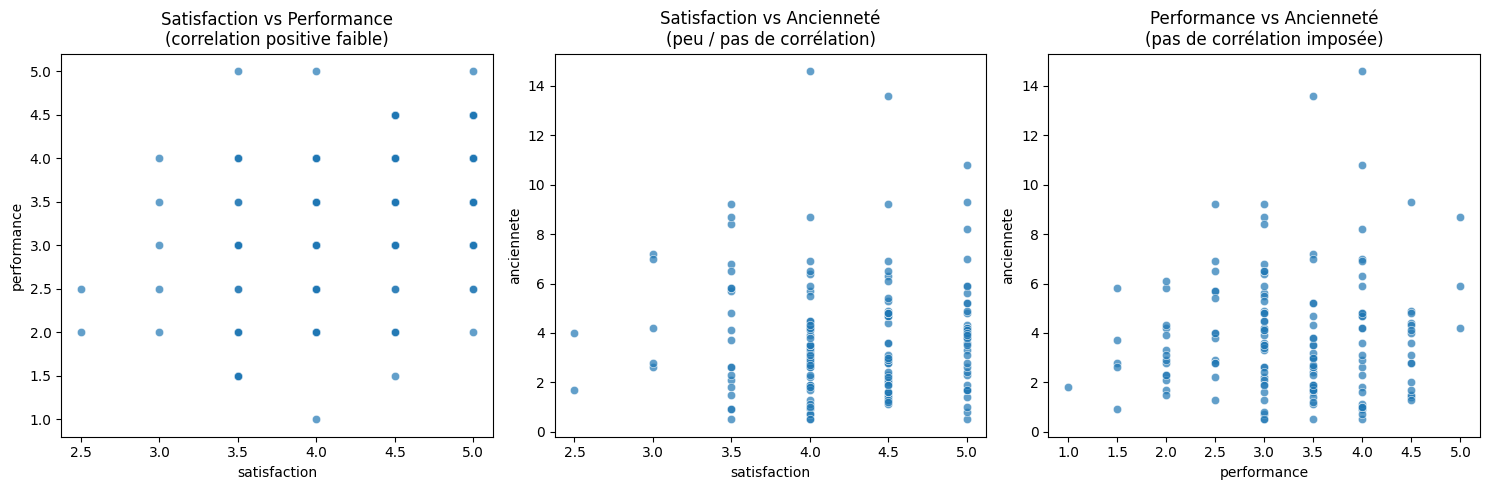

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paramètres
np.random.seed(42)
n = 150  # 150 collaborateurs

# Ancienneté (en années)
anciennete = np.random.gamma(2, 2, n).clip(0.5, 25)  # 0.5 à 25 ans

# Performance (1 à 5, score RH)
performance = np.clip(np.random.normal(3.2, 0.8, n), 1, 5)
performance = np.round(performance * 2) / 2  # demi‑points

# Satisfaction liée à la performance, mais avec du bruit
# On veut une corrélation positive mais faible
noise_perf = np.random.normal(0, 1, n)
satisfaction_raw = 0.4 * performance + 0.6 * noise_perf + 3.0
satisfaction = np.clip(satisfaction_raw, 1, 5)
satisfaction = np.round(satisfaction * 2) / 2  # 1.0, 1.5, …, 5.0

# Ancienneté presque indépendante de la satisfaction
# On ajoute un tout petit lien pour rester réaliste, mais très faible
satisfaction_with_anciennete = satisfaction + 0.05 * (anciennete - anciennete.mean())

# On redonne des valeurs RH lisibles
df = pd.DataFrame({
    "collab_id": range(1, n + 1),
    "age": np.random.randint(22, 60, n),
    "anciennete": np.round(anciennete, 1),
    "performance": performance,
    "satisfaction": satisfaction,
})

# Matrice de corrélation
corr = df[["anciennete", "performance", "satisfaction"]].corr(method="pearson")

# Affichage
print("==> Matrice de corrélation (Pearson)")
print(corr)

# Scatter plots pour illustrer visuellement
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=df, x="satisfaction", y="performance", alpha=0.7, ax=axes[0])
axes[0].set_title("Satisfaction vs Performance\n(correlation positive faible)")

sns.scatterplot(data=df, x="satisfaction", y="anciennete", alpha=0.7, ax=axes[1])
axes[1].set_title("Satisfaction vs Ancienneté\n(peu / pas de corrélation)")

sns.scatterplot(data=df, x="performance", y="anciennete", alpha=0.7, ax=axes[2])
axes[2].set_title("Performance vs Ancienneté\n(pas de corrélation imposée)")

plt.tight_layout()
plt.show()